# AUTO INSURANCE CLAIM PROPENSITY USING GLM

## **Executive Summary** ##

This project develops and validates an interpretable binomial Generalized Linear Model (GLM) to estimate auto insurance claim propensity using policyholder, vehicle, and geographic characteristics. The dataset contains 58,592 policies and an observed claim rate of approximately 6.4%. Because the response indicates whether a policy recorded at least one claim, the model estimates claim occurrence probability rather than claim frequency, severity, or expected loss cost.

I evaluated a sequence of candidate models using likelihood-ratio tests, AIC, and holdout performance. Model 2, which includes nonlinear customer age, vehicle age, fuel type, and region, was selected as the final model. Adding geography produced a statistically significant improvement over the core model, while vehicle segment and safety features provided little additional value.

On the holdout sample, Model 2 achieved a ROC-AUC of 0.5765 and predicted an aggregate claim rate of 6.40%, closely matching the observed rate. Although individual-level discrimination is modest, the model provides useful broad risk separation: the observed claim rate increases from approximately 3.9% in the lowest predicted-risk decile to 9.1% in the highest.

Given these results, the model is best viewed as a risk-segmentation, underwriting-support, and portfolio-monitoring tool rather than a standalone pricing model. A production pricing framework would require reliable exposure information together with claim frequency and severity modeling.

## 1. Business Problem

Auto insurers need to distinguish expected risk across policyholders so that underwriting and pricing decisions reflect differences in expected loss experience.

In this project, the response variable indicates whether a policy recorded at least one claim during the observation period.

This project estimates:
$$
P(Y_i = 1 | X_i)
$$
where:
$$
Y_i = 
\begin{cases}
1, &\text{if policy } i \text{ made a claim}\\
0, &\text{otherwise}
\end{cases}
$$
A binomial GLM with a logit link function is used:
$$
log(\frac{p_i}{1-p_i}) = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \cdot + \beta_n X_{in}
$$

The primary objectives are to identify statistically and practically relevant risk characteristics, quantify adjusted differences in claim propensity, evaluate the model's ability to segment risk, and translate the results into useful underwriting insights.

This should not be interpreted as a complete insurance pricing model. Claim severity is not available, and reliable exposure information is limited. A traditional expected-loss framework would require both claim frequency and severity:
$$
\text{Expected Loss Cost} = \text{Claim Frequency} \times \text{Claim Severity}
$$

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import chi2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from patsy.contrasts import Treatment

pd.set_option("display.max_columns", 100)


In [2]:
DATA_PATH = Path("insurance_claims_data.csv")
df = pd.read_csv(DATA_PATH)

## 2. Data Preparation & Feature Engineering

### 2.1. Data Overview and Quality Checks

In [3]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Policy records",
        "Variables",
        "Claims",
        "Non-claims",
        "Observed claim rate",
        "Duplicate rows",
        "Unique policy IDs",
        "Missing values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        (df["claim_status"] == 1).sum(),
        (df["claim_status"] == 0).sum(),
        f"{df["claim_status"].mean():.2%}",
        df.duplicated().sum(),
        df["policy_id"].nunique(),
        df.isna().sum().sum()
    ]
})

portfolio_summary 

,Metric,Value
0,Policy records,58592
1,Variables,41
2,Claims,3748
3,Non-claims,54844
4,Observed claim rate,6.40%
5,Duplicate rows,0
6,Unique policy IDs,58592
7,Missing values,0


**Variable-role table:**

In [4]:
variable_table = pd.DataFrame({
    "Variable family": [
        "Identifier",
        "Target variable",
        "Potential exposure",
        "Policyholder",
        "Geographic",
        "Vehicle",
        "Safety",
        "Specifications"
    ],
    "Names": [
        "policy_id",
        "claim_status",
        "subscription_length",
        "customer_age",
        "region_code, region_density",
        "vehicle_age, segment, fuel_type, displacement",
        "is_esc, is_tpms, airbags, is_adjustable_steering, etc.",
        "max_torque, max_power"
    ],
    "Modeling role": [
        "Exclude",
        "Response",
        "Special treatment",
        "Candidate risk factor",
        "Candidate risk factors",
        "Candidate risk factors",
        "Candidate risk factors",
        "Engineer before modeling"
    ]
})

variable_table 

,Variable family,Names,Modeling role
0,Identifier,policy_id,Exclude
1,Target variable,claim_status,Response
2,Potential exposure,subscription_length,Special treatment
3,Policyholder,customer_age,Candidate risk factor
4,Geographic,"region_code, region_density",Candidate risk factors
5,Vehicle,"vehicle_age, segment, fuel_type, displacement",Candidate risk factors
6,Safety,"is_esc, is_tpms, airbags, is_adjustable_steeri...",Candidate risk factors
7,Specifications,"max_torque, max_power",Engineer before modeling


### 2.2. Targest Distribution & Modeling Considerations

**Target Distribution**

In [5]:
assert df["claim_status"].isin([0, 1]).all()
assert df["policy_id"].notna().all()

print(df["claim_status"].value_counts(normalize=True).rename(index={0: "No claim", 1: "Claim"}))

claim_status
No claim    0.936032
Claim       0.063968
Name: proportion, dtype: float64


Claims represent approximately 6.4% of the portfolio, so the response is naturally imbalanced. This is not, by itself, a data-quality problem. For the primary GLM, I retain the observed class distribution so that predicted probabilities remain aligned with the underlying portfolio claim rate. Alternative imbalance treatments are evaluated later as challenger models.

In [6]:
model_df = df.drop(columns=["policy_id"]).copy()

**Examples of Some Distributions**

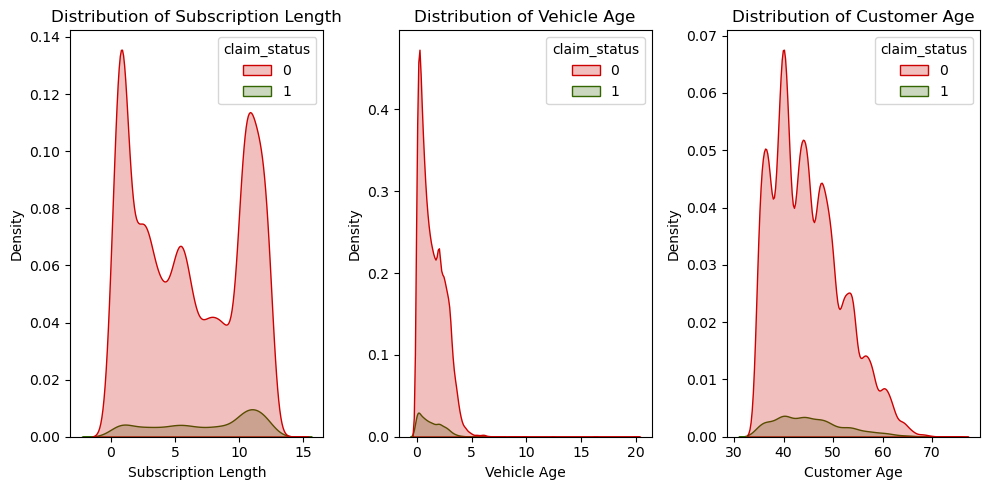

In [7]:
numerical_columns = model_df[['subscription_length', 'vehicle_age', 'customer_age']].columns
plt.figure(figsize=(10, 5))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=model_df, x=col, hue='claim_status', fill=True, palette=['#cc0000', '#336600'])
    plt.xlabel(f'{" ".join([el.title() for el in col.split("_")])}')
    plt.title(f'Distribution of {" ".join([el.title() for el in col.split("_")])}')
plt.tight_layout()
plt.show()

**Categorical Variable Treatment**

In [8]:
yes_no_cols = [
    "is_esc",
    "is_adjustable_steering",
    "is_tpms",
    "is_parking_sensors",
    "is_parking_camera",
    "is_front_fog_lights",
    "is_rear_window_wiper",
    "is_rear_window_washer",
    "is_rear_window_defogger",
    "is_brake_assist",
    "is_power_door_locks",
    "is_central_locking",
    "is_power_steering",
    "is_driver_seat_height_adjustable",
    "is_day_night_rear_view_mirror",
    "is_ecw",
    "is_speed_alert"
]

for col in yes_no_cols:
    if col in model_df.columns:
        model_df[col] = pd.Categorical(
            model_df[col], categories=["No", "Yes"]
        )

In [9]:
model_df["fuel_type"] = pd.Categorical(
    model_df["fuel_type"],
    categories=["Petrol", "Diesel", "CNG"]
)

### 2.3. Feature Engineering for `torque_max` and `power_max`

In [10]:
# engineering for maximum torque
def extract_nm_rpm(series):
    parsed = series.astype(str).str.extract(
        r"(?P<nm>\d+(?:\.\d+)?)\D+@(?P<rpm>\d+(?:\.\d+)?)"
    )

    parsed["nm"] = pd.to_numeric(
        parsed["nm"],
        errors="coerce"
    )

    parsed["rpm"] = pd.to_numeric(
        parsed["rpm"],
        errors="coerce"
    )

    return parsed


torque_parsed = extract_nm_rpm(
    model_df["max_torque"]
)

model_df["torque_nm"] = torque_parsed["nm"]
model_df["torque_rpm"] = torque_parsed["rpm"]

# engineering for maximum power
def extract_bhp_rpm(series):
    parsed = series.astype(str).str.extract(
        r"(?P<bhp>\d+(?:\.\d+)?)\D+@(?P<rpm>\d+(?:\.\d+)?)"
    )

    parsed["bhp"] = pd.to_numeric(
        parsed["bhp"],
        errors="coerce"
    )

    parsed["rpm"] = pd.to_numeric(
        parsed["rpm"],
        errors="coerce"
    )

    return parsed


power_parsed = extract_bhp_rpm(
    model_df["max_power"]
)

model_df["power_bhp"] = power_parsed["bhp"]
model_df["power_rpm"] = power_parsed["rpm"]

In [11]:
pd.DataFrame({
    "variable": ["torque_nm", "torque_rpm", "power_bhp", "power_rpm"],
    "parse_rate": [
        model_df["torque_nm"].notna().mean(),
        model_df["torque_rpm"].notna().mean(),
        model_df["power_bhp"].notna().mean(),
        model_df["power_rpm"].notna().mean()
    ]
})

,variable,parse_rate
0,torque_nm,1.0
1,torque_rpm,1.0
2,power_bhp,1.0
3,power_rpm,1.0


### 2.4. Splitting Data 

In [12]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    stratify=model_df["claim_status"],
    random_state=42
)

split_summary = pd.DataFrame({
    "Sample": ["Trainning", "Test"],
    "Policies": [
        len(train_df),
        len(test_df)
    ],
    "Claim Rate": [
        train_df["claim_status"].mean(),
        test_df["claim_status"].mean()
    ]
})

split_summary

,Sample,Policies,Claim Rate
0,Trainning,43944,0.063968
1,Test,14648,0.063968


The data is split into a 75% development sample and a 25% holdout sample using stratified random sampling, which preserves the 6.4% claim rate in both samples. Model fitting and model selection are performed on the development sample, while the holdout sample is reserved for out-of-sample validation.

## 3. Exploratory Risk & Exposure Analysis

In [13]:
from statsmodels.stats.proportion import proportion_confint
import matplotlib.ticker as mtick

def risk_table(data, feature):
    result = (data.groupby(feature, observed=True)["claim_status"].agg(
            policies="size",
            claims="sum",
            claim_rate="mean"
        ).reset_index()
    )

    lower, upper = proportion_confint(
        count=result["claims"],
        nobs=result["policies"],
        method="wilson"
    )

    result["ci_lower"] = lower
    result["ci_upper"] = upper

    portfolio_rate = data["claim_status"].mean()

    result["relativity"] = (result["claim_rate"] / portfolio_rate)

    return result

def plot_claim_rate_ci(data, feature, title, xlabel):
    summary=(data.groupby(feature, observed=True).agg(
        policies=("claim_status", "size"),
        claims=("claim_status", "sum"),
        claim_rate=("claim_status", "mean")
    ).reset_index())

    lower, upper = proportion_confint(
        count=summary["claims"],
        nobs=summary["policies"],
        method="wilson",
    )

    summary["ci_lower"]=lower
    summary["ci_upper"]=upper

    overall_rate= data["claim_status"].mean()

    summary["relativity"]=(summary["claim_rate"]/overall_rate)

    x = np.arange(len(summary))
    y = summary["claim_rate"].to_numpy()

    yerr = np.vstack([
        y - summary["ci_lower"].to_numpy(),
        summary["ci_upper"].to_numpy() - y
    ])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=5, markersize=7)
    ax.axhline(overall_rate, linestyle="--", label=f"Portfolio average ({overall_rate:.2%})")
    ax.set_xticks(x)
    ax.set_xticklabels(summary[feature].astype(str))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Observed Claim Rate")

    # Show exposures
    for i, row in summary.reset_index(drop=True).iterrows():
        ax.annotate(
            f"n={row['policies']:,}",
            xy=(i, row["ci_lower"]),
            xytext=(0, -18),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

    ax.legend()
    plt.tight_layout()
    plt.show()

    return summary
    

### 3.1. Policyholder & Vehicle Risk Analysis

**1. Customer Age**

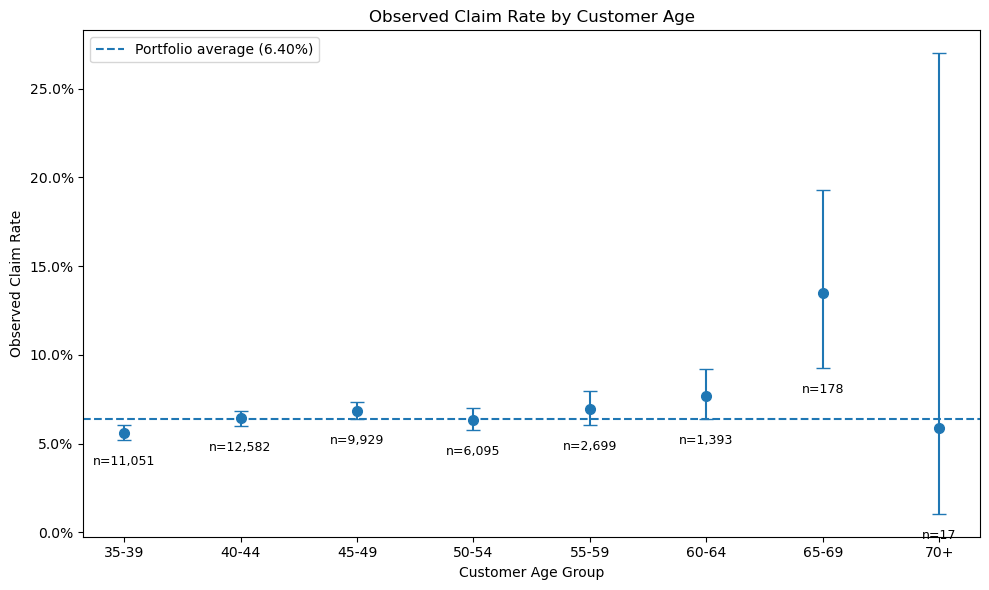

,customer_age_range,policies,claims,claim_rate,ci_lower,ci_upper,relativity
0,35-39,11051,619,0.056013,0.051878,0.060457,0.875644
1,40-44,12582,807,0.064139,0.059990,0.068555,1.002681
2,45-49,9929,679,0.068386,0.063586,0.073519,1.069062
3,50-54,6095,387,0.063495,0.057643,0.069896,0.992604
4,55-59,2699,187,0.069285,0.060304,0.079490,1.083122
5,60-64,1393,107,0.076813,0.063963,0.091990,1.200802
6,65-69,178,24,0.134831,0.092308,0.192783,2.107803
7,70+,17,1,0.058824,0.010460,0.269820,0.919581


In [14]:
age_bins = [35, 40, 45, 50, 55, 60, 65, 70, np.inf]
age_labels = ["35-39", "40-44", "45-49", "50-54", "55-59", "60-64","65-69", "70+"]

train_df = train_df.copy()

train_df["customer_age_range"] = pd.cut(
    train_df["customer_age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_risk_plot = plot_claim_rate_ci(
    data=train_df,
    feature="customer_age_range",
    title="Observed Claim Rate by Customer Age",
    xlabel="Customer Age Group"
)
age_risk_plot

Observed claim rates vary across customer-age groups, with some evidence of higher claim propensity at older ages. However, the oldest groups contain relatively few policies and therefore have wider confidence intervals. These results are univariate and may also reflect differences in vehicle type, geography, or other characteristics. Customer age is therefore evaluated jointly with the other predictors in the GLM.

**2. Vehicle Age**

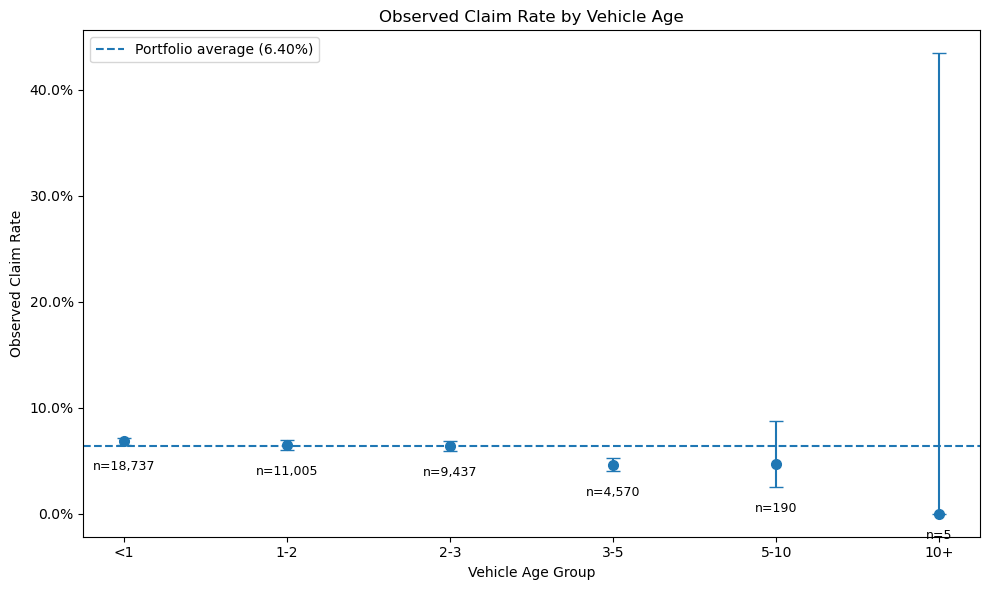

,vehicle_age_range,policies,claims,claim_rate,ci_lower,ci_upper,relativity
0,<1,18737,1277,0.068154,0.064633,0.071852,1.065441
1,1-2,11005,715,0.064970,0.060516,0.069729,1.015675
2,2-3,9437,601,0.063685,0.058934,0.068792,0.995587
3,3-5,4570,209,0.045733,0.040048,0.052181,0.714939
4,5-10,190,9,0.047368,0.025118,0.087559,0.740504
5,10+,5,0,0.000000,0.000000,0.434482,0.000000


In [15]:
vehicle_age_bins = [0, 1, 2, 3, 5, 10, np.inf]

vehicle_age_labels = ["<1", "1-2", "2-3", "3-5", "5-10", "10+"]

train_df["vehicle_age_range"] = pd.cut(
    train_df["vehicle_age"],
    bins=vehicle_age_bins,
    labels=vehicle_age_labels,
    right=False
)

vehicle_age_risk_plot = plot_claim_rate_ci(
    data=train_df,
    feature="vehicle_age_range",
    title="Observed Claim Rate by Vehicle Age",
    xlabel="Vehicle Age Group"
)
vehicle_age_risk_plot

Claim occurrence also varies by vehicle age. Vehicles in the 3-5 year group show a lower observed claim rate than newer vehicles, but exposure becomes very limited in the oldest groups. In particular, estimates for vehicles older than five years have wide confidence intervals and should not be interpreted as credible rating indications. The vehicle-age tail is therefore consolidated before model fitting.

### 3.2 Exposure Considerations

`subscription_length` may capture time at risk, since a policy observed for a longer period has more opportunity to record at least one claim. As a result, an association between subscription length and claim occurrence could reflect exposure rather than an underlying difference in policyholder risk.

Because the dataset does not establish that `subscription_length` is a valid insurance exposure measure, I do not include it as a standard rating factor in the primary GLM. Its potential exposure role is evaluated separately as a sensitivity test.

### 3.3 Geographic Risk Analysis

In [16]:
region_risk = risk_table(train_df, "region_code")

region_risk = region_risk.merge(
    train_df[["region_code", "region_density"]].drop_duplicates(), on="region_code", how="left"
)

region_risk.sort_values("claim_rate", ascending=False)

,region_code,policies,claims,claim_rate,ci_lower,ci_upper,relativity,region_density
9,C18,183,18,0.098361,0.063126,0.150111,1.537659,35036
5,C14,2761,217,0.078595,0.069132,0.089228,1.228661,7788
14,C22,141,11,0.078014,0.044118,0.134294,1.219586,16733
10,C19,753,56,0.074369,0.057713,0.095346,1.162604,27742
13,C21,285,21,0.073684,0.048696,0.110012,1.151896,3264
16,C4,489,36,0.073620,0.053649,0.100237,1.150886,21622
15,C3,4586,328,0.071522,0.064417,0.079344,1.118095,4076
20,C8,10139,707,0.069731,0.064934,0.074853,1.090092,8794
11,C2,5519,377,0.068309,0.061950,0.075270,1.067873,27003
18,C6,669,44,0.065770,0.049356,0.087142,1.028171,13051


Observed claim rates vary meaningfully across regions, but regional results need to be interpreted together with policy volume. Smaller regions produce wider confidence intervals, so unusually high or low rates may reflect sampling variation rather than stable underlying risk. Regional effects are therefore evaluated again in the multivariate GLM and through holdout O/E validation.

### 3.4. Safety Feature Risk Analysis

In [17]:
safety_features = [
    "is_esc",
    "is_tpms",
    "is_adjustable_steering",
    "is_parking_sensors",
    "is_parking_camera",
    "is_brake_assist",
    "airbags"
]

safety_tables = {
    feature: risk_table(train_df, feature)
    for feature in safety_features
}

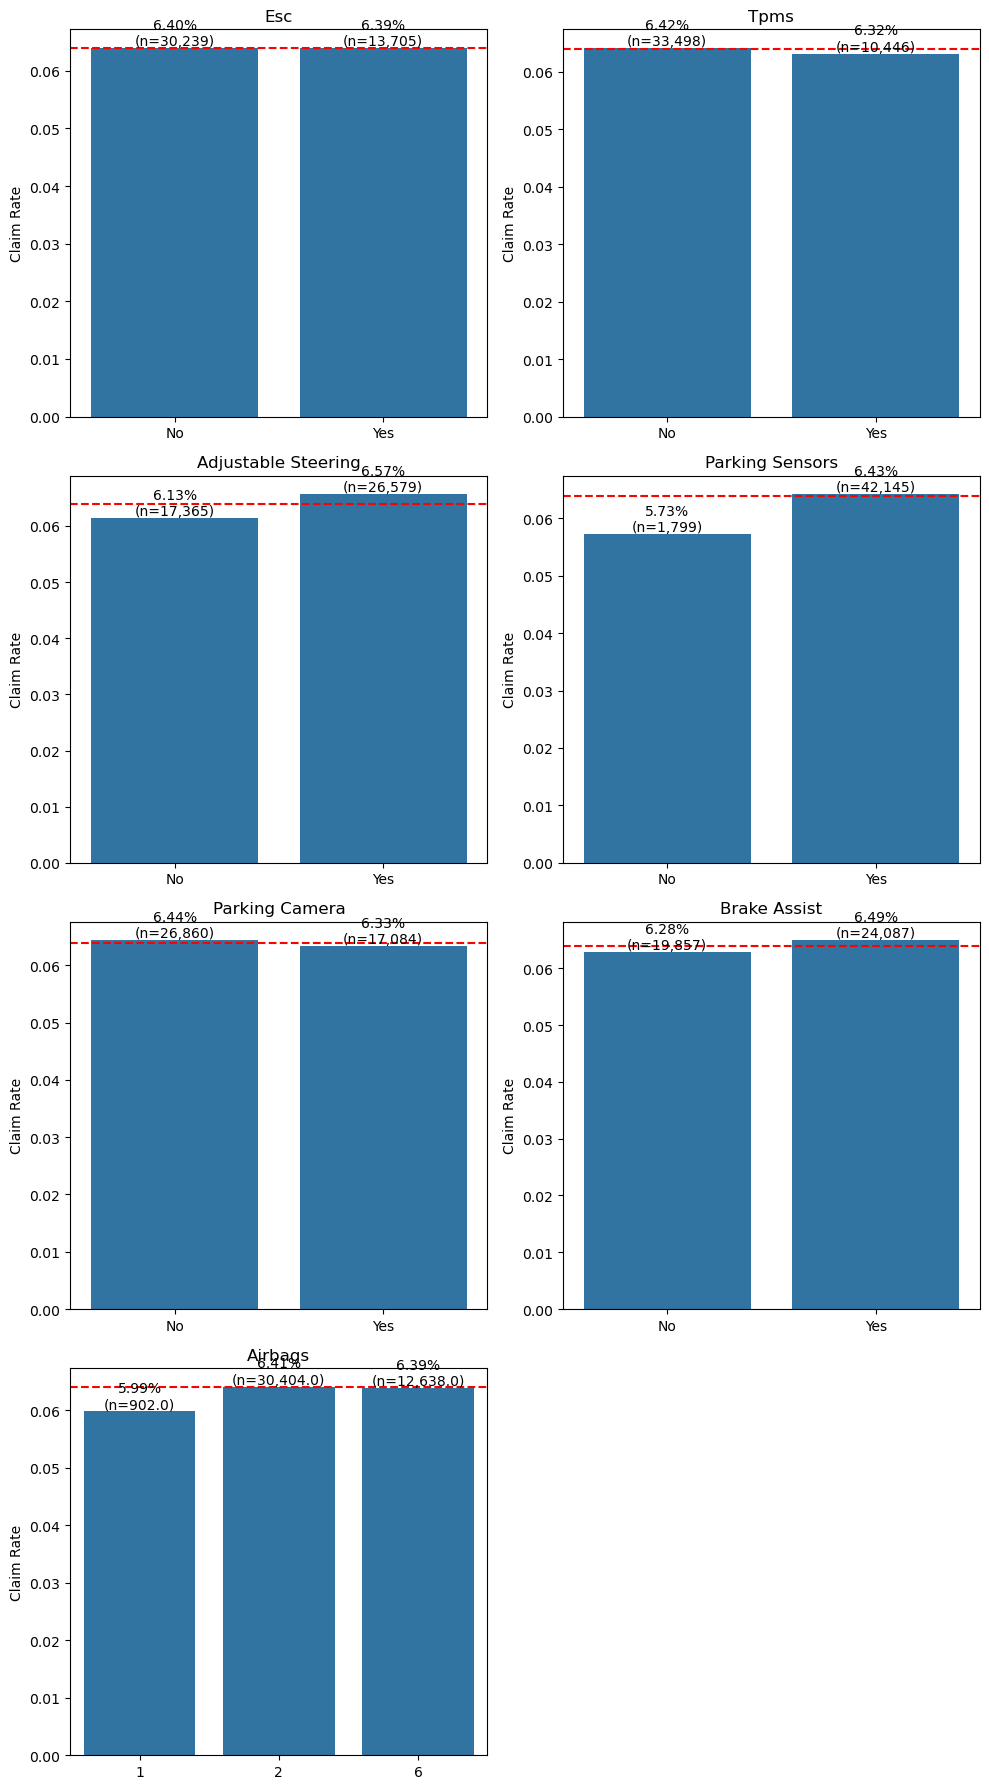

In [18]:
overall_rate = train_df["claim_status"].mean()

fig, axes = plt.subplots(4, 2, figsize=(10, 18))
axes = axes.flatten()
for ax, feature in zip(axes, safety_features):
    table = safety_tables[feature]
    sns.barplot(data=table, x=feature, y="claim_rate", ax=ax)
    ax.axhline(overall_rate, linestyle="--", color="red")
    for bar, (_, row) in zip(ax.patches, table.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{row['claim_rate']:.2%}\n(n={row['policies']:,})",
            ha="center",
            va="bottom",
        )
    ax.set_title(feature.replace("is_", "").replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Claim Rate")

#remove 8th plot
for ax in axes[len(safety_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

Observed claim rates differ across several vehicle safety features, although most differences are relatively small. Policy counts are shown alongside each rate to provide context for the stability of the estimates. Because these comparisons are univariate, they may also reflect differences in vehicle model, segment, age, or other correlated characteristics. Their incremental contribution is therefore evaluated later within the GLM.

### 3.5. Volume and Stability Analysis

**Customer Age & Vehicle Age Heatmap**

In [19]:
rate_matrix = train_df.pivot_table(
    values="claim_status",
    index="customer_age_range",
    columns="vehicle_age_range",
    aggfunc="mean",
    observed=True
)

count_matrix = train_df.pivot_table(
    values="claim_status",
    index="customer_age_range",
    columns="vehicle_age_range",
    aggfunc="size",
    observed=True
)

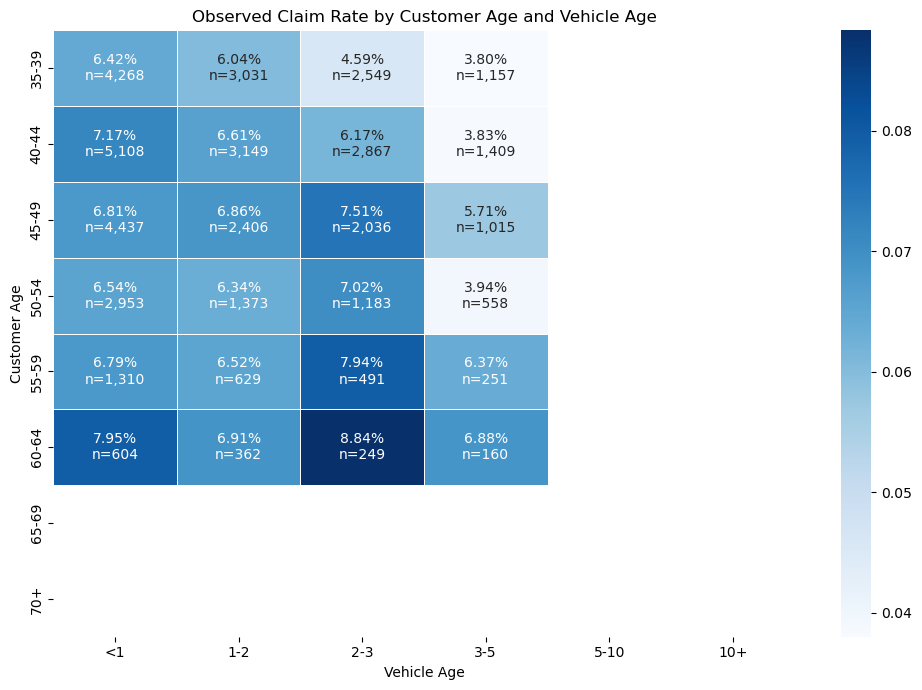

In [20]:
labels = rate_matrix.copy().astype(object)
for row in rate_matrix.index:
    for col in rate_matrix.columns:
        rate = rate_matrix.loc[row, col]
        n = count_matrix.loc[row, col]
        if pd.notna(rate):
            labels.loc[row, col]=(f"{rate:.2%}\n"f"n={n:,.0f}")
            
min_policies = 100

plt.figure(figsize=(10, 7))
sns.heatmap(
    rate_matrix,
    annot=labels,
    fmt='',
    cmap='Blues',
    mask=count_matrix < min_policies,
    linewidths=0.5
)
plt.title("Observed Claim Rate by Customer Age and Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Customer Age")
plt.tight_layout()
plt.show()

Claim occurrence is also examined across combinations of customer age and vehicle age. Cells with fewer than 100 policies are suppressed to reduce the risk of overinterpreting highly unstable observed rates. The 100-policy threshold is used as a practical screening rule rather than as a formal actuarial credibility standard.

These results remain exploratory and unadjusted. Differences across cells may reflect correlated policyholder, vehicle, or geographic characteristics that are addressed later in the multivariate model.

**Safety Features Heatmap**

In [21]:
safety_long = train_df.melt(
    id_vars='claim_status',
    value_vars=safety_features,
    var_name='feature',
    value_name='status'
)

safety_summary = (
    safety_long.groupby(['feature', 'status'], observed=True)['claim_status'].agg(['mean', 'count']) .reset_index()
)

sf_rate_matrix = safety_summary.pivot(
    index='feature', 
    columns='status', 
    values='mean'
)
sf_count_matrix = safety_summary.pivot(
    index='feature',
    columns='status',
    values='count'
)


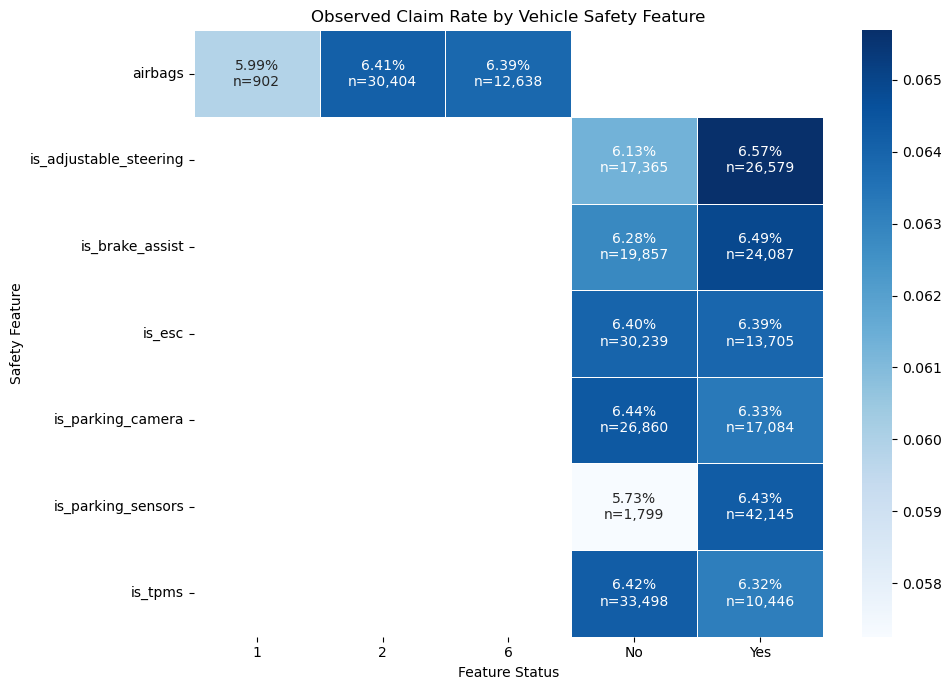

In [22]:
sf_labels = sf_rate_matrix.copy().astype(object)
for row in sf_rate_matrix.index:
    for col in sf_rate_matrix.columns:
        rate = sf_rate_matrix.loc[row, col]
        n = sf_count_matrix.loc[row, col]
        if pd.notna(rate):
            sf_labels.loc[row, col]=(f"{rate:.2%}\n"f"n={n:,.0f}")
            
plt.figure(figsize=(10, 7))
sns.heatmap(
    sf_rate_matrix,
    annot=sf_labels,
    fmt='',
    cmap='Blues',
    mask=sf_count_matrix < min_policies,
    linewidths=0.5
)
plt.title('Observed Claim Rate by Vehicle Safety Feature')
plt.xlabel('Feature Status')
plt.ylabel('Safety Feature')
plt.tight_layout()
plt.show()

## 4. GLM Development

### 4.1. Building Models

In [23]:
def fit_logit_glm(formula, data):
    return smf.glm(
    formula=formula,
    data=data,
    family=sm.families.Binomial(
        link=sm.families.links.Logit()
    )
).fit()

In [24]:
# collapse the sparse vehecile-age tail
vehicle_age_bins =[0, 1, 2, 3, np.inf]
vehicle_age_labels = ["<1", "1-2","2-3","3+"]

for data in [train_df, test_df]:
    data["vehicle_age_range"] = pd.cut(
        data["vehicle_age"], 
        bins=vehicle_age_bins,
        labels=vehicle_age_labels,
        right=False
    )

#group airbags into fewer level because airbag (1) = 902, creating imbalance
train_df["airbags_group"] = train_df["airbags"].apply(
    lambda x: "1 or 2" if x<=2 else "6"
)

In [25]:
## model 0: Null model
m0_formula = "claim_status ~ 1"
m0= fit_logit_glm(m0_formula, train_df)

## model 1: core vehicle/demographic model
m1_formula = """
        claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75)
                    + C(vehicle_age_range) 
                    + C(fuel_type)
"""
m1= fit_logit_glm(m1_formula, train_df)

## model 2: adding geography
m2_formula = """
        claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75) 
                        + C(vehicle_age_range) 
                        + C(fuel_type) 
                        + C(region_code)
"""
m2 = fit_logit_glm(m2_formula, train_df)

## model 3:adding segment
m3_formula ="""
    claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75) 
                    + C(vehicle_age_range) 
                    + C(fuel_type) 
                    + C(region_code) 
                    + C(segment) 
"""
m3 = fit_logit_glm(m3_formula, train_df)

# model 4: adding safety features
m4_formula ="""
    claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75) 
                    + C(vehicle_age_range) 
                    + C(fuel_type) 
                    + C(region_code) 
                    + C(segment) 
                    + C(is_esc) 
                    + C(is_tpms) 
                    + C(is_adjustable_steering) 
                    + C(is_parking_camera) 
                    + C(is_brake_assist) 
                    + C(airbags_group)
"""
m4 = fit_logit_glm(m4_formula, train_df)

In [26]:
model_table = pd.DataFrame({
    "Model": ["M0", "M1", "M2", "M3", "M4"],
    "AIC": [m0.aic, m1.aic, m2.aic, m3.aic, m4.aic],
    "Deviance": [m0.deviance, m1.deviance, m2.deviance, m3.deviance, m4.deviance],
    "DF Model": [m0.df_model, m1.df_model, m2.df_model, m3.df_model, m4.df_model]
})
model_table

,Model,AIC,Deviance,DF Model
0,M0,20897.215715,20895.215715,0
1,M1,20851.847744,20831.847744,9
2,M2,20825.213920,20763.213920,30
3,M3,20830.364837,20758.364837,35
4,M4,20830.947621,20752.947621,38


### 4.2. Likehood-Ratio Tests

In [27]:
from scipy.stats import chi2

def lr_test(smaller_model, larger_model):
    lr_stat = 2*(larger_model.llf - smaller_model.llf)

    df_diff = (larger_model.df_model - smaller_model.df_model)

    p_value = chi2.sf(lr_stat, df_diff)

    return pd.Series({
        "Likehood-Ratio statistics:": lr_stat,
        "df:": df_diff,
        "p-value:": p_value
    })

**Model 1 vs. Model 2**

In [28]:
lr_test(m1,m2)

Likehood-Ratio statistics:    6.863382e+01
df:                           2.100000e+01
p-value:                      5.808702e-07
dtype: float64

Adding geography materially improves model fit. The likelihood-ratio statistic is 68.6 on 21 degrees of freedom, with a p-value of approximately $5.8\times10^{-7}$. This provides strong evidence that regional information contributes additional signal for claim occurrence beyond customer age, vehicle age, and fuel type.

**Model 2 vs. Model 3**

In [29]:
lr_test(m2,m3)

Likehood-Ratio statistics:    4.849083
df:                           5.000000
p-value:                      0.434575
dtype: float64

Adding vehicle segment does not significantly improve fit relative to Model 2 (LR = 4.85, df = 5, p = 0.435). Given the additional complexity and limited incremental value, vehicle segment is not retained in the selected model.

**Model 3 vs. Model 4**

In [30]:
lr_test(m3,m4)

Likehood-Ratio statistics:    5.417216
df:                           3.000000
p-value:                      0.143675
dtype: float64

Adding the selected safety features also does not significantly improve model fit (LR = 5.42, df = 3, p = 0.144). The additional terms therefore do not provide enough incremental value to justify the added model complexity.

### 4.3. Model Evaluation

In [31]:
# group airbags for the test data before evaluating
test_df["airbags_group"] = test_df["airbags"].apply(
    lambda x: "1 or 2" if x<=2 else "6"
)

def evaluate_model(model, test_data):
    y_true = test_data["claim_status"]
    y_pred = model.predict(test_data)

    return {
        "AIC": model.aic,
        "ROC-AUC": roc_auc_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_pred),
        "Log Loss": log_loss(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_pred),
        "Predict Claim Rate": y_pred.mean(),
        "Actual Claim Rate": y_true.mean()
    }

In [32]:
evaluation_table = pd.DataFrame({
    "Model 1": evaluate_model(m1, test_df),
    "Model 2": evaluate_model(m2, test_df),
    "Model 3": evaluate_model(m3, test_df),
    "Model 4": evaluate_model(m4, test_df)
}).T
evaluation_table

,AIC,ROC-AUC,PR-AUC,Log Loss,Brier Score,Predict Claim Rate,Actual Claim Rate
Model 1,20851.847744,0.562171,0.078234,0.236352,0.059714,0.063981,0.063968
Model 2,20825.213920,0.576499,0.085337,0.235600,0.059609,0.063986,0.063968
Model 3,20830.364837,0.577061,0.085782,0.235510,0.059600,0.063991,0.063968
Model 4,20830.947621,0.576561,0.085002,0.235521,0.059603,0.064014,0.063968


Models 2, 3, and 4 all improve on Model 1, although the gains are modest. Model 2 increases ROC-AUC from 0.5622 to 0.5765 and PR-AUC from 0.0782 to 0.0853 while slightly improving Log Loss and Brier Score.

Model 3 produces the strongest holdout metrics, but the improvement over Model 2 is negligible: ROC-AUC increases by only about 0.0006, while Log Loss and Brier Score change by less than 0.0001. Model 2 also has the lowest AIC, and the likelihood-ratio test does not support adding vehicle segment.

Model 2 is therefore selected as the final model because it provides essentially the same predictive performance as the more complex alternatives while remaining more parsimonious and easier to interpret. Its aggregate calibration is also strong, with a predicted claim rate of 6.3986% compared with an observed holdout rate of 6.3968%.

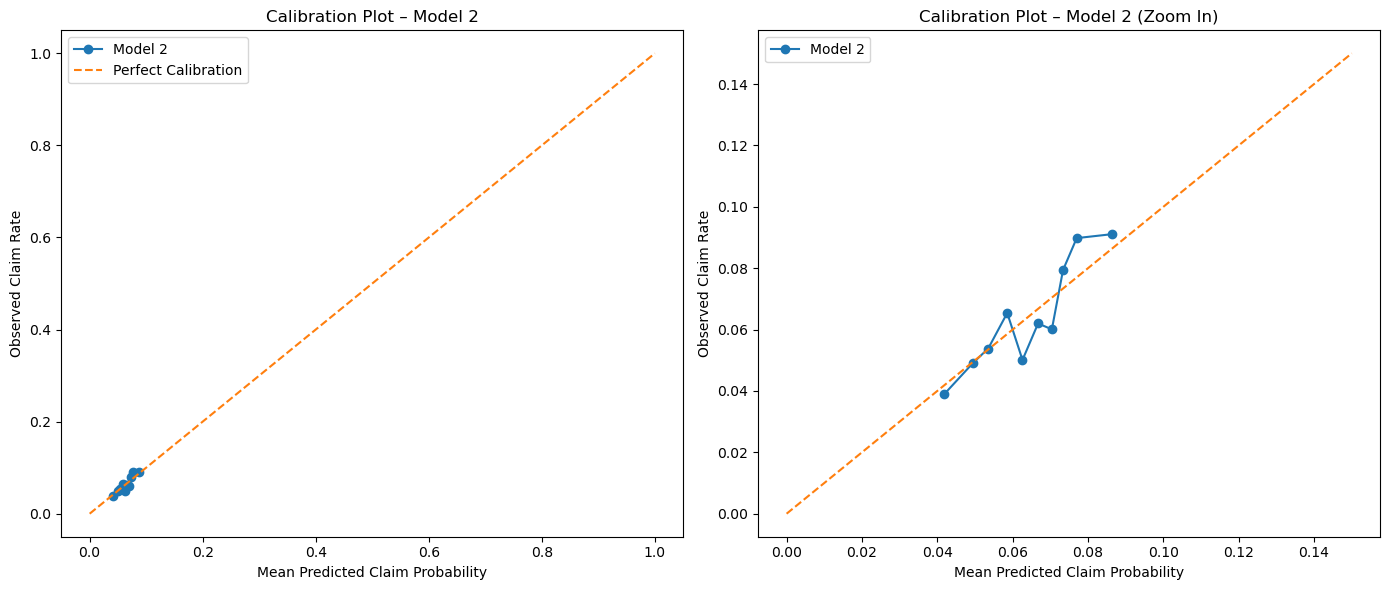

In [33]:
y_true = test_df["claim_status"]
y_pred_m2 = m2.predict(test_df)

prob_true, prob_pred = calibration_curve(
                        y_true, 
                        y_pred_m2, 
                        n_bins=10,
                        strategy="quantile"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(prob_pred, prob_true, marker="o", label="Model 2")
axes[0].plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
axes[0].set_xlabel("Mean Predicted Claim Probability")
axes[0].set_ylabel("Observed Claim Rate")
axes[0].set_title("Calibration Plot – Model 2")
axes[0].legend()

axes[1].plot(prob_pred, prob_true, marker="o", label="Model 2")
axes[1].plot([0, 0.15], [0, 0.15], linestyle="--")
axes[1].set_xlabel("Mean Predicted Claim Probability")
axes[1].set_ylabel("Observed Claim Rate")
axes[1].set_title("Calibration Plot – Model 2 (Zoom In)")
axes[1].legend()

plt.tight_layout()
plt.show()

#### 4.3.1 Observed-Expected Analysis

In [34]:
validation = test_df.copy()

validation["predicted_claim_prob"] = m2.predict(test_df)

validation["customer_age_range"] = pd.cut(
    validation["customer_age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

def oe_table(test_data, group_col, min_policies=100):
    table = (
        test_data.groupby(group_col, observed=True).agg(
            policies=("claim_status", "size"),
            observed_claims=("claim_status", "sum"),
            expected_claims=("predicted_claim_prob", "sum"),
            observed_rate=("claim_status", "mean"),
            expected_rate=("predicted_claim_prob", "mean")
        ).reset_index()
    )

    table["O/E"] = (table["observed_claims"])/(table["expected_claims"])
    table["calibration_gap"] = (table["observed_rate"] - table["expected_rate"])

    portfolio_rate = test_data["claim_status"].mean()
    table["lift"] =(table["observed_rate"])/portfolio_rate

    table["volume_flag"] = np.where(
        table["policies"] >= min_policies,
        "Adequate Volume", "Low Volume"
    )

    return table

**A. Overall O/E Analysis**

In [35]:
overall_observed_claims = validation["claim_status"].sum()
overall_expected_claims = validation["predicted_claim_prob"].sum()
overall_oe_ratio = overall_observed_claims/overall_expected_claims

print("Observed Claims:", overall_observed_claims)
print("Expected Claims:", overall_expected_claims)
print("O/E Ratio:", overall_oe_ratio)

Observed Claims: 937
Expected Claims: 937.2709878492572
O/E Ratio: 0.9997108756669413


The holdout sample contains 937 observed claims compared with approximately 937.3 expected claims, producing an overall O/E ratio of 0.9997. This indicates excellent aggregate calibration. However, portfolio-level agreement can conceal offsetting overprediction and underprediction within individual segments, so O/E is also reviewed by predicted-risk decile and key rating characteristics.

**B. O/E Analysis by Risk Deciles**

In [36]:
validation["risk_decile"] = pd.qcut(
    validation["predicted_claim_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

oe_by_decile = oe_table(validation, "risk_decile")
oe_by_decile

,risk_decile,policies,observed_claims,expected_claims,observed_rate,expected_rate,O/E,calibration_gap,lift,volume_flag
0,1,1467,57,61.277743,0.038855,0.041771,0.930191,-0.002916,0.607412,Adequate Volume
1,2,1464,72,72.508714,0.049180,0.049528,0.992984,-0.000347,0.768830,Adequate Volume
2,3,1468,79,78.548724,0.053815,0.053507,1.005745,0.000307,0.841278,Adequate Volume
3,4,1468,96,85.964860,0.065395,0.058559,1.116735,0.006836,1.022313,Adequate Volume
4,5,1457,73,91.225757,0.050103,0.062612,0.800213,-0.012509,0.783253,Adequate Volume
5,6,1468,91,97.987595,0.061989,0.066749,0.928689,-0.004760,0.969068,Adequate Volume
6,7,1465,88,103.146730,0.060068,0.070407,0.853154,-0.010339,0.939039,Adequate Volume
7,8,1461,116,107.195481,0.079398,0.073371,1.082135,0.006026,1.241214,Adequate Volume
8,9,1470,132,113.187670,0.089796,0.076998,1.166205,0.012798,1.403768,Adequate Volume
9,10,1460,133,126.227715,0.091096,0.086457,1.053651,0.004639,1.424090,Adequate Volume


Model 2 provides useful separation between the tails of the predicted-risk distribution. The lowest-risk decile has an observed claim rate of approximately 3.9%, compared with 9.1% in the highest-risk decile, so the highest predicted-risk group experiences more than 2.3 times the claim propensity of the lowest group.

The relationship is not perfectly monotonic across the middle deciles. However, this is consistent with the model's modest ROC-AUC and suggests that the model is better suited to broad segmentation than to highly granular individual risk ranking.

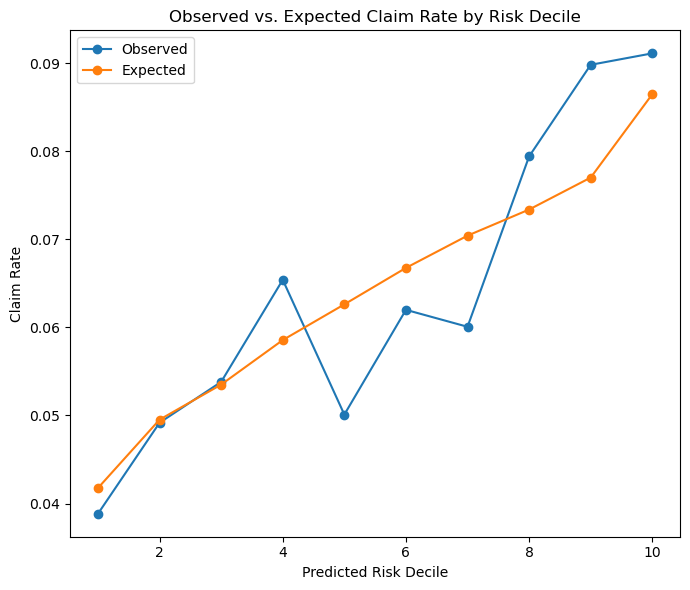

In [37]:
plt.figure(figsize=(7, 6))

plt.plot(
    oe_by_decile["risk_decile"],
    oe_by_decile["observed_rate"],
    marker="o",
    label="Observed"
)
plt.plot(
    oe_by_decile["risk_decile"],
    oe_by_decile["expected_rate"],
    marker="o",
    label="Expected"
)
plt.xlabel("Predicted Risk Decile")
plt.ylabel("Claim Rate")
plt.title("Observed vs. Expected Claim Rate by Risk Decile")
plt.legend()
plt.tight_layout()
plt.show()


**C. O/E Analysis by Key Rating Characteristics**

In [38]:
oe_by_customer_age = oe_table(validation, "customer_age_range")
#oe_by_customer_age

In [39]:
oe_by_vehicle_age = oe_table(validation, "vehicle_age_range")
#oe_by_vehicle_age

In [40]:
oe_by_region = oe_table(validation, "region_code")
#oe_by_region

In [41]:
def plot_oe(table, group_col, title):

    plt.figure(figsize=(6, 4))

    plt.plot(table[group_col].astype(str), table["O/E"], marker="o")

    plt.axhline(1.0, linestyle="--", label="Perfect O/E")

    plt.xlabel(group_col.replace("_", " ").title())
    plt.ylabel("Observed / Expected Ratio")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


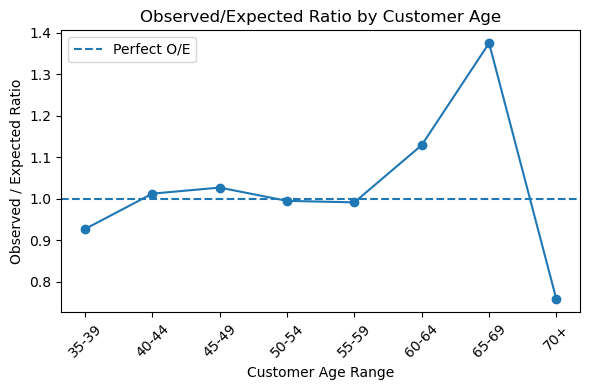

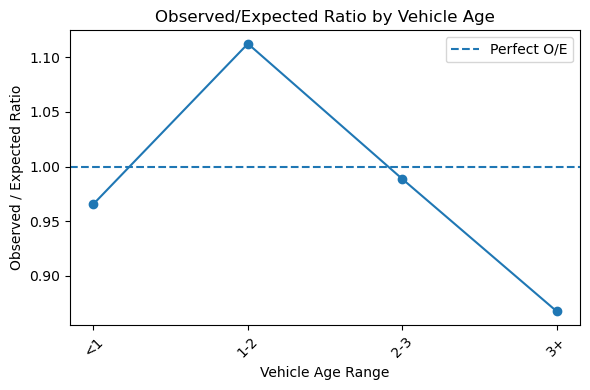

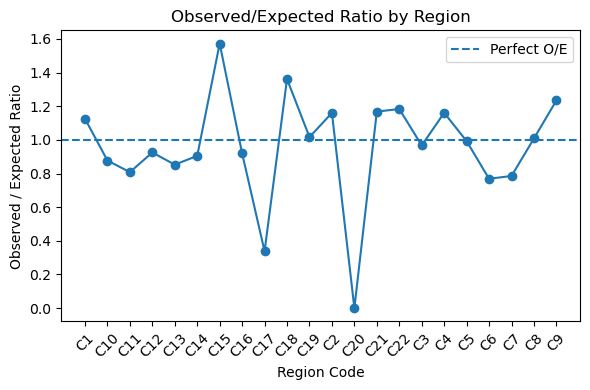

In [42]:
plot_oe(oe_by_customer_age, "customer_age_range", "Observed/Expected Ratio by Customer Age")
plot_oe(oe_by_vehicle_age, "vehicle_age_range", "Observed/Expected Ratio by Vehicle Age")
plot_oe(oe_by_region, "region_code", "Observed/Expected Ratio by Region")

In [43]:
def oe_summary(table, segment_name):
    weighted_abs_gap = np.average(
        np.abs(table["observed_rate"] - table["expected_rate"]), weights=table["policies"]
    )
    return {
        "Validation Segment": segment_name,
        "Number of Groups": len(table),
        "Minimum O/E": table["O/E"].min(),
        "Maximum O/E": table["O/E"].max(),
        "Weighted Avg. Absolute Calibration Gap": weighted_abs_gap,
        "Low-Credibility Groups": (table["volume_flag"] == "Low Volume").sum()
    }

In [44]:
oe_validation_summary = pd.DataFrame([
    oe_summary(oe_by_customer_age, "Customer Age"),
    oe_summary(oe_by_vehicle_age, "Vehicle Age"),
    oe_summary(oe_by_region, "Region"),
    oe_summary(oe_by_decile, "Risk Decile")
])
oe_validation_summary

,Validation Segment,Number of Groups,Minimum O/E,Maximum O/E,Weighted Avg. Absolute Calibration Gap,Low-Credibility Groups
0,Customer Age,8,0.757235,1.375130,0.002300,2
1,Vehicle Age,4,0.867222,1.112543,0.003665,0
2,Region,22,0.000000,1.572409,0.005943,4
3,Risk Decile,10,0.800213,1.166205,0.006146,0


The validation results support the use of *Model 2* for broad risk segmentation. Calibration appears strongest for customer age and vehicle age, while geography requires greater credibility review and ongoing monitoring. The model therefore provides useful portfolio-level and segment-level risk differentiation, but localized deviations reinforce that it should support, rather than replace, actuarial and underwriting judgment.

#### 4.3.2 Selected Model Coefficients and Adjusted Odds Ratios 

Model 2 coefficients are translated into adjusted odds ratios to evaluate the direction and magnitude of each modeled risk factor. An odds ratio above 1.00 indicates higher claim odds relative to the reference level, while an odds ratio below 1.00 indicates lower claim odds, holding the other model variables constant.

In [45]:
# adding reference because of categorial odds ratio relative to its reference level
m2_formula = """
    claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75)
                + C(vehicle_age_range, Treatment(reference="<1"))
                + C(fuel_type, Treatment(reference="Petrol"))
                + C(region_code, Treatment(reference="C1"))
"""

m2 = fit_logit_glm(m2_formula,train_df)

In [46]:
coef_table = pd.DataFrame({
    "coefficient": m2.params,
    "std_error": m2.bse,
    "p-value": m2.pvalues
})

ci = m2.conf_int()

coef_table["odds_ratio"] = np.exp(m2.params)
coef_table["ci_lower"] = np.exp(ci[0])
coef_table["ci_upper"] = np.exp(ci[1])

relativity_table = coef_table[
    (coef_table.index != "Intercept") &
    (~coef_table.index.str.contains(r"bs\(customer_age"))
].copy()

# clean factor names
relativity_table["factor"] = np.select(
    [
        relativity_table.index.str.contains("vehicle_age_range"),
        relativity_table.index.str.contains("fuel_type"),
        relativity_table.index.str.contains("region_code")
    ],
    [
        "Vehicle Age",
        "Fuel Type",
        "Region"
    ],
    default="Other"
)

relativity_table["level"] = (relativity_table.index.str.extract(r"\[T\.(.*?)\]", expand=False))

# Direction of effect
relativity_table["direction"] = np.where(
    relativity_table["odds_ratio"] > 1,
    "Higher",
    "Lower"
)

relativity_table = relativity_table[
    [
        "factor",
        "level",
        "coefficient",
        "odds_ratio",
        "ci_lower",
        "ci_upper",
        "p-value",
        "direction"
    ]
]


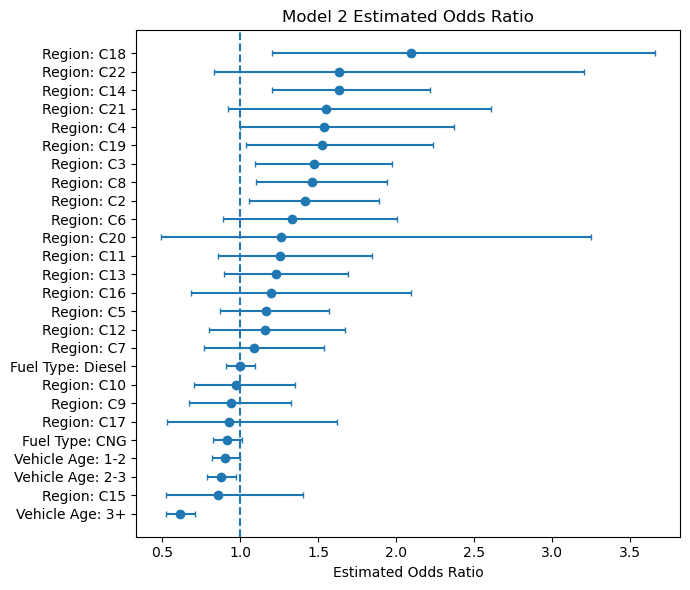

In [47]:
relativity_plot = relativity_table.copy()
relativity_plot = relativity_plot[relativity_plot.index != "Intercept"].copy()
relativity_plot = relativity_plot.sort_values("odds_ratio")

labels = (
    relativity_plot["factor"]
    + ": "
    + relativity_plot["level"].astype(str)
)

plt.figure(figsize=(7,6))
plt.errorbar(
    relativity_plot["odds_ratio"],
    range(len(relativity_plot)),
    xerr=[
        relativity_plot["odds_ratio"] - relativity_plot["ci_lower"],
        relativity_plot["ci_upper"] - relativity_plot["odds_ratio"]
    ],
    fmt="o",
    capsize=2
)
plt.axvline(1, linestyle="--")
plt.yticks(range(len(relativity_plot)), labels)
plt.xlabel("Estimated Odds Ratio")
plt.ylabel("")
plt.title("Model 2 Estimated Odds Ratio")
plt.tight_layout()
plt.show()

Vehicle age and geography show the clearest adjusted relationships with claim propensity. Relative to vehicles less than one year old, the estimated claim odds decline as vehicle age increases, with the largest reduction observed for vehicles aged three years or more.

Several regions also show materially higher adjusted claim odds relative to the C1 reference region. In particular, C14, C18, C19, C2, C3, and C8 have confidence intervals that remain above 1.00. Other regions have point estimates above the reference but wider confidence intervals, so those differences should be interpreted more cautiously.

Fuel type shows little evidence of a meaningful adjusted difference in this specification. Customer age is modeled using a spline and is therefore interpreted through fitted probabilities across age rather than individual spline coefficients.

#### 4.3.3. Exposure GLM Sensitivity Test

In [48]:
positive_exposure_train = (train_df["subscription_length"] > 0)
positive_exposure_test = (test_df["subscription_length"] > 0)

train_cloglog= (train_df.loc[positive_exposure_train].copy())
test_cloglog = (test_df.loc[positive_exposure_test].copy())

cloglog_formula="""
    claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75) 
                    + C(vehicle_age_range) 
                    + C(fuel_type) 
                    + C(region_code)  
"""
exposure_model = smf.glm(
    formula=cloglog_formula,
    data=train_cloglog,
    family=sm.families.Binomial(
        link=sm.families.links.CLogLog()
    ),
    offset=np.log(train_cloglog["subscription_length"])
).fit()

In [49]:
def evaluate_exp_model(model, test_data):
    y_true = test_data["claim_status"]
    y_exp_pred = model.predict(test_data, offset=np.log(test_data["subscription_length"]))

    return {
        "AIC": model.aic,
        "ROC-AUC": roc_auc_score(y_true, y_exp_pred),
        "PR-AUC": average_precision_score(y_true, y_exp_pred),
        "Log Loss": log_loss(y_true, y_exp_pred),
        "Brier Score": brier_score_loss(y_true, y_exp_pred),
        "Predict Claim Rate": y_exp_pred.mean(),
        "Actual Claim Rate": y_true.mean()
    }
evaluation_table = pd.DataFrame({
    "Model 2": evaluate_model(m2, test_df),
    "Exposure Model": evaluate_exp_model(exposure_model, test_cloglog)
})
evaluation_table

,Model 2,Exposure Model
AIC,20825.213920,21399.616922
ROC-AUC,0.576499,0.624185
PR-AUC,0.085337,0.093841
Log Loss,0.235600,0.238636
Brier Score,0.059609,0.059680
Predict Claim Rate,0.063986,0.063908
Actual Claim Rate,0.063968,0.064171


The exposure model produces a different performance tradeoff from the primary Model 2. It improves ranking performance, with ROC-AUC increasing from 0.5765 to 0.6242 and PR-AUC from 0.0853 to 0.0938. However, its probability accuracy is slightly weaker, as reflected in the higher Log Loss and Brier Score.

Aggregate calibration remains reasonably close for both models. The exposure model predicts a 6.39% claim rate compared with an observed rate of approximately 6.42% on the applicable holdout sample.

These results suggest that incorporating `subscription_length` as an exposure offset may contain useful information. However, because the dataset does not establish that `subscription_length` represents true earned insurance exposure, I retain Model 2 as the primary model and treat the complementary log-log specification as a sensitivity analysis rather than a production frequency model.

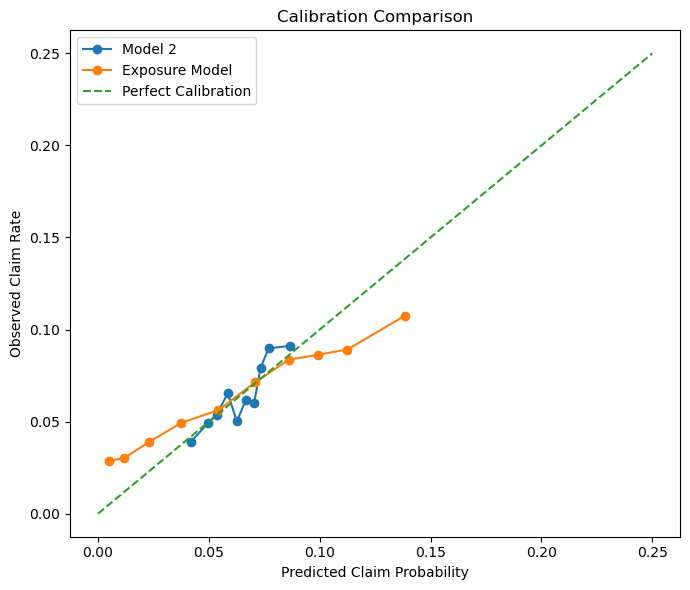

In [50]:
y_exp_true = test_cloglog["claim_status"]
y_exp_pred = exposure_model.predict(test_cloglog, offset=np.log(test_cloglog["subscription_length"]))

exp_true, exp_pred = calibration_curve(
                        y_exp_true, 
                        y_exp_pred, 
                        n_bins=10,
                        strategy="quantile"
)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model 2")
plt.plot(exp_pred, exp_true, marker="o", label="Exposure Model")

plt.plot([0, 0.25], [0, 0.25], linestyle="--", label="Perfect Calibration")
plt.xlabel("Predicted Claim Probability")
plt.ylabel("Observed Claim Rate")
plt.title("Calibration Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Challenger Modeling Pipeline 

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

In [52]:
categorical_features = [
    "vehicle_age_range",
    "region_code",
    "fuel_type",
]

numeric_features = [
    "customer_age"
]

preprocessor = ColumnTransformer([
    (
        "age_spline",
     SplineTransformer(
         n_knots=4,
         degree=3,
         include_bias=False
     ),
     ["customer_age"]
    ),
    (
        "categorical",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

In [53]:
# natural logistic 
natural_lr = Pipeline([
    ("preprocess", preprocessor),
    (
        "model", LogisticRegression(penalty=None, max_iter=1000)
    )
])

# weighted log
weighted_lr = Pipeline([
    ("preprocess", preprocessor),
    (
        "model", LogisticRegression(penalty=None, class_weight="balanced", max_iter=1000)
    )
])

# random oversampling
oversampled_lr = ImbPipeline([
    ("preprocess", preprocessor),
    (
        "oversample", RandomOverSampler(random_state=42)
    ),
    (
        "model", LogisticRegression(penalty=None, max_iter=1000)
    )
])

In [54]:
# fitting the challenger models
X_train = train_df[categorical_features + numeric_features]
Y_train = train_df["claim_status"]
X_test = test_df[categorical_features + numeric_features]
Y_test = test_df["claim_status"]

natural_lr.fit(X_train, Y_train)
weighted_lr.fit(X_train, Y_train)
oversampled_lr.fit(X_train, Y_train)

natural_prob = natural_lr.predict_proba(X_test)[:, 1]
weighted_prob = weighted_lr.predict_proba(X_test)[:, 1]
oversampled_prob = oversampled_lr.predict_proba(X_test)[:, 1]

In [55]:
def evaluate_probabilities(y_true, y_prob):
  return {
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "Predict Claim Rate": y_prob.mean(),
        "Actual Claim Rate": y_true.mean()
    }

challenger_table = pd.DataFrame({
    "Model 2": evaluate_probabilities(y_true, y_pred_m2),
    "Natural LR": evaluate_probabilities(y_true, natural_prob),
    "Weighted LR": evaluate_probabilities(y_true, weighted_prob),
    "Oversampled LR": evaluate_probabilities(y_true, oversampled_prob)
}).T

challenger_table

,ROC-AUC,PR-AUC,Log Loss,Brier Score,Predict Claim Rate,Actual Claim Rate
Model 2,0.576499,0.085337,0.235600,0.059609,0.063986,0.063968
Natural LR,0.578449,0.085821,0.235629,0.059614,0.063905,0.063968
Weighted LR,0.576158,0.085714,0.686324,0.246683,0.494450,0.063968
Oversampled LR,0.576018,0.085477,0.686124,0.246602,0.494261,0.063968


The natural logistic-regression (LR) challenger produces results that are nearly identical to Model 2. Its ROC-AUC and probability-error metrics are marginally better, but the differences are too small to represent a meaningful improvement in practical predictive performance.

The class-weighted and oversampled models maintain similar ranking performance, but their raw predicted probabilities are severely miscalibrated. Both produce average predicted claim rates of approximately 49%, compared with an observed rate of only 6.4%. This occurs because weighting and oversampling alter the class balance used during estimation; without a separate probability-correction or recalibration step, those probabilities should not be interpreted as portfolio claim probabilities.

For this project, preserving interpretable and well-calibrated probabilities is more important than forcing greater emphasis on the minority class. The naturally distributed GLM therefore remains the preferred modeling framework.

### 4.5. Vehicle Specification Sensitivity Test

In [56]:
spec_vars = ["displacement", "torque_nm", "power_bhp"]

m2_specs_formula = """
        claim_status ~ bs(customer_age, df=4, lower_bound=35, upper_bound=75) 
                        + C(vehicle_age_range) 
                        + C(fuel_type) 
                        + C(region_code)
                        + displacement
                        + torque_nm
                        + power_bhp
"""

m2_specs = fit_logit_glm(m2_specs_formula, train_df)

lr_test(m2, m2_specs)

Likehood-Ratio statistics:    4.060925
df:                           3.000000
p-value:                      0.254960
dtype: float64

Since `p_value = 0.255` there is not enough evidence that the specifications improve *Model 2* jointly. 

In [57]:
evaluation_table = pd.DataFrame({
    "Model 2": evaluate_model(m2, test_df),
    "Model 2 and Specifications": evaluate_model(m2_specs, test_df)
}).T
evaluation_table

,AIC,ROC-AUC,PR-AUC,Log Loss,Brier Score,Predict Claim Rate,Actual Claim Rate
Model 2,20825.213920,0.576499,0.085337,0.235600,0.059609,0.063986,0.063968
Model 2 and Specifications,20827.152995,0.574844,0.084652,0.235631,0.059616,0.063989,0.063968


Vehicle displacement, torque, and power were evaluated as additional candidate predictors. The likelihood-ratio test does not provide evidence that these variables improve Model 2 jointly (p = 0.255), and their inclusion does not materially improve holdout performance. They are therefore excluded from the selected model to preserve parsimony and interpretability.

## 5. Business Interpretation

The selected GLM can be used to convert individual policy characteristics into an adjusted claim-propensity score. Rather than treating the predicted probability as a direct premium indication, policies can be ranked into lower-, average-, and higher-risk segments. This provides an interpretable framework for underwriting review, portfolio segmentation, and risk monitoring.

On the holdout sample, the lowest predicted-risk decile had an observed claim rate of approximately 3.9%, compared with 9.1% in the highest-risk decile, meaning the highest-scoring group experienced more than twice the claim propensity of the lowest-scoring group. However, the model's ROC-AUC of approximately 0.58 indicates only modest individual-level discrimination, and the middle deciles are not perfectly monotonic. Therefore, Model 2 is best used as a broad risk-ranking and underwriting support tool rather than a standalone pricing or individual claim-classification model.

## 6. Limitations

This model predicts claim occurrence only and does not capture claim counts or claim severity. It therefore cannot estimate expected loss cost or serve as a complete insurance pricing model. In addition, `subscription_length` may not represent true insurance exposure, which limits the ability to interpret the response as an exposure-adjusted claim frequency.

Several customer-age, vehicle-age, and regional segments also contain limited policy volume, making their observed rates and estimated effects less stable. Model discrimination remains modest (ROC-AUC ≈ 0.58), indicating that a substantial portion of individual claim variation is not explained by the available predictors.

Finally, the analysis uses a random holdout sample rather than temporal or out-of-time validation. Future performance may change as geographic risk, vehicle technology, portfolio mix, and underlying loss experience evolve. A production model would therefore require stronger exposure data, out-of-time validation, and ongoing O/E monitoring across key risk segments.